# Trajectory Optimization in Uncertain Environments
**Author:** Aditya Joshi | Student ID: 2530019

**Sections:**
1. Imports & Setup
2. Environment Preview
3. Nominal iLQR Trajectory
4. Controller Rollouts (with limited sensing)
5. Navigation Animation — dropdown to switch controller
6. Tracking Error & Control Effort over Time
7. Metrics Comparison

---
## 1. Imports & Setup

In [ ]:
import sys, os, functools
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown
%matplotlib widget

# Environment
from environment.dynamics     import ContinuousTimeSpaceshipDynamics
from environment.integrators  import RK4Integrator
from environment.asteroid_env import Environment
from environment.ilqr         import (
    iterative_linear_quadratic_regulator,
    TotalCost, RunningCost, FullHorizonTerminalCost,
    compute_nominal_trajectory,
)

# Controllers
from controllers.pid            import PositionPIDController, FullStatePIDController
from controllers.state_feedback import StateFeedbackController, InfiniteHorizonLQRController

# Sensing simulation
from utils.sensing  import simulate_with_sensing
from utils.metrics  import evaluate_controller

# Config
from config import (
    T, dt, start_state, goal_position,
    Q, R, STATE_DIM, CONTROL_DIM,
    RANDOM_SEED, NUM_ASTEROIDS, LIMITED_SENSING,
    R_LIMIT, A_LIMIT,
)

np.random.seed(RANDOM_SEED)
dynamics = RK4Integrator(ContinuousTimeSpaceshipDynamics(), dt)
env      = Environment.create(NUM_ASTEROIDS)

COLORS = {
    'PID (position)':   '#e74c3c',
    'PID (full-state)': '#e67e22',
    'State Feedback':   '#2ecc71',
    'Inf-Horizon LQR':  '#3498db',
}

---
## 2. Environment Preview
Scrub the slider to watch asteroids move over time.

interactive(children=(IntSlider(value=0, description='Step k', max=125), Output()), _dom_classes=('widget-inte…

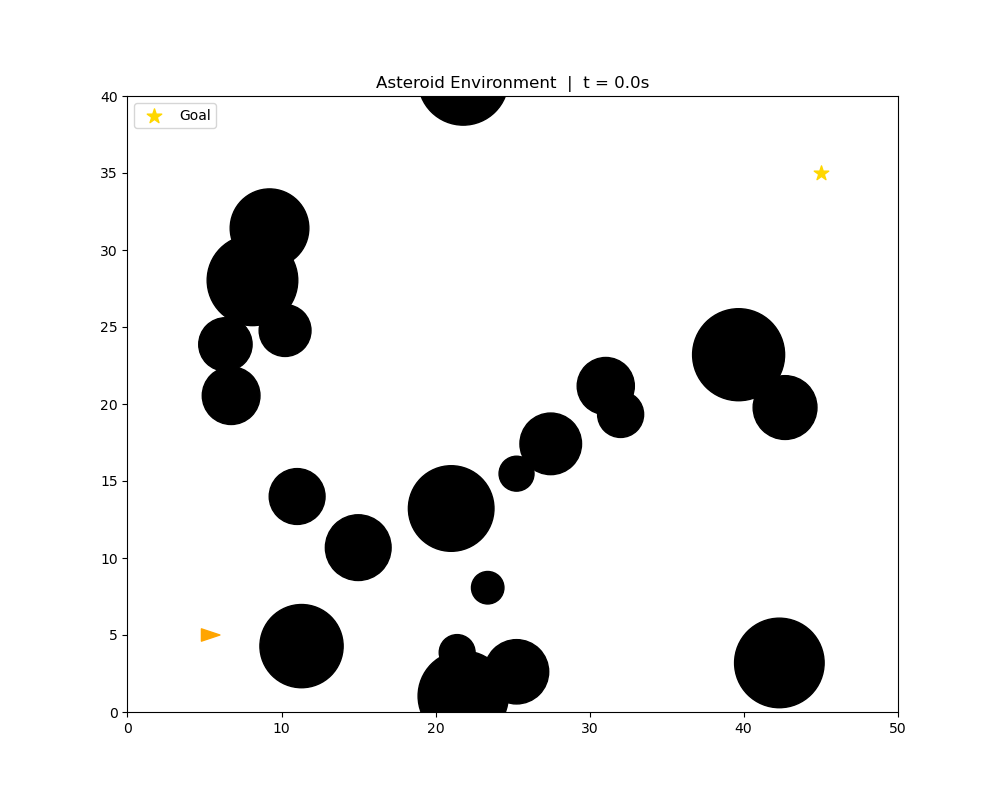

In [ ]:
fig_env, ax_env = env.plot(state=start_state)
ax_env.scatter(*goal_position, s=120, marker='*', color='gold', zorder=20, label='Goal')
ax_env.legend(loc='upper left')

@interact(k=IntSlider(min=0, max=T, step=1, value=0, description='Step k'))
def animate_env(k=0):
    env.at_time(k * dt).plot(state=start_state, ax=ax_env)
    ax_env.set_title(f'Asteroid Environment  |  t = {k * dt:.1f}s')
    fig_env.canvas.draw_idle()

---
## 3. Nominal iLQR Trajectory
Two-stage warm-start: solve on empty env first, then full asteroid field.
This reference trajectory is tracked by all controllers.

In [ ]:
solution = compute_nominal_trajectory(
    dynamics, env, start_state, goal_position, T, verbose=True
)
xs_nom, us_nom = solution['optimal_trajectory']

Stage 1: empty environment... done (10 iters)
Stage 2: full asteroid environment... done (100 iters, cost=17371.36)


interactive(children=(IntSlider(value=0, description='Step k', max=125), Output()), _dom_classes=('widget-inte…

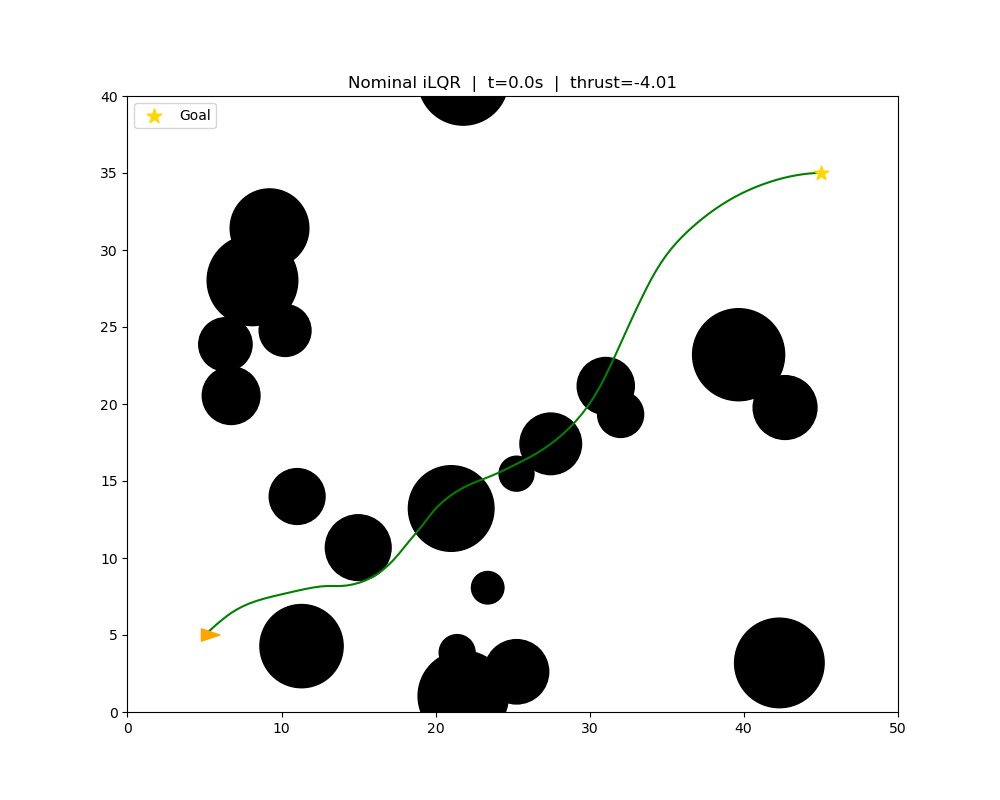

In [ ]:
# Animate nominal trajectory
fig_nom, ax_nom = env.plot(state=start_state, plan=xs_nom, history=xs_nom[:1])
ax_nom.scatter(*goal_position, s=120, marker='*', color='gold', zorder=20, label='Goal')
ax_nom.legend(loc='upper left')

@interact(k=IntSlider(min=0, max=T, step=1, value=0, description='Step k'))
def animate_nominal(k=0):
    thrust = float(us_nom[min(k, T-1), 1]) / 4.0
    env.at_time(k * dt).plot(
        state         = xs_nom[k],
        plan          = xs_nom[k:],
        history       = xs_nom[:k+1],
        scaled_thrust = thrust,
        sensor        = False,
        ax            = ax_nom,
    )
    ax_nom.set_title(f'Nominal iLQR  |  t={k*dt:.1f}s  |  thrust={us_nom[min(k,T-1),1]:.2f}')
    fig_nom.canvas.draw_idle()

---
## 4. Controller Rollouts with Limited Sensing
Each controller navigates with `sensing_radius` visibility only.
Asteroids outside that radius are invisible — the ship must avoid
what it can see and track the nominal path otherwise.

In [ ]:
# Instantiate all controllers
pid_pos = PositionPIDController(
    Kp_pos=1.0, Ki_pos=0.01, Kd_pos=0.5,
    Kp_heading=2.0, Kp_speed=1.0, Kd_speed=0.3,
    r_limit=R_LIMIT, a_limit=A_LIMIT, dt=dt,
)

pid_full = FullStatePIDController(
    Kp_x=1.0, Kd_x=0.5, Ki_x=0.01,
    Kp_y=1.0, Kd_y=0.5, Ki_y=0.01,
    Kp_th=2.0, Kd_th=0.3,
    Kp_vx=0.5, Kd_vx=0.1,
    Kp_vy=0.5, Kd_vy=0.1,
    r_limit=R_LIMIT, a_limit=A_LIMIT, dt=dt,
)

sf_ctrl = StateFeedbackController(dynamics=dynamics, Q=Q, R=R,
                                   r_limit=R_LIMIT, a_limit=A_LIMIT)
sf_ctrl.prepare(xs_nom, us_nom)

lqr_ctrl = InfiniteHorizonLQRController(dynamics=dynamics, Q=Q, R=R,
                                         r_limit=R_LIMIT, a_limit=A_LIMIT)
lqr_ctrl.prepare(xs_nom, us_nom)

controllers = {
    'PID (position)':   pid_pos,
    'PID (full-state)': pid_full,
    'State Feedback':   sf_ctrl,
    'Inf-Horizon LQR':  lqr_ctrl,
}
print('Controllers ready.')

[StateFeedback] Computing LQR gains... done.
[InfiniteHorizonLQR] Solving DARE at midpoint... done.
Controllers ready.


In [ ]:
# Run all controllers with limited sensing
# simulate_with_sensing applies env.sense() at each step so the
# controller only reacts to asteroids within sensing_radius.
results = {}
for name, ctrl in controllers.items():
    print(f'Running: {name} ...', end=' ', flush=True)
    res = simulate_with_sensing(
        ctrl, start_state, env, dynamics,
        xs_nom, us_nom, goal_position,
        T=T, dt=dt, limited_sensing=LIMITED_SENSING,
        verbose=False,
    )
    results[name] = res
    status = '✓' if res['success'] else ('collision' if res['collision'] else 'timeout')
    print(f'{status}  |  track={np.mean(res["tracking_errors"]):.2f}m  '
          f'effort={np.mean(res["control_efforts"]):.2f}  '
          f'time={res["traversal_time"]} steps')

Running: PID (position) ... collision  |  track=4.88m  effort=2.80  time=125 steps
Running: PID (full-state) ... collision  |  track=2.15m  effort=5.92  time=125 steps
Running: State Feedback ... collision  |  track=0.44m  effort=11.30  time=111 steps
Running: Inf-Horizon LQR ... collision  |  track=10.25m  effort=17.04  time=125 steps


---
## 5. Navigation Animation
Use the **dropdown** to switch controller.
Use the **slider** to scrub through time.

The dashed circle is the sensing radius — only asteroids inside it are visible to the controller.
Green line = nominal reference. Colored trail = actual path taken.

interactive(children=(Dropdown(description='Controller', options=('PID (position)', 'PID (full-state)', 'State…

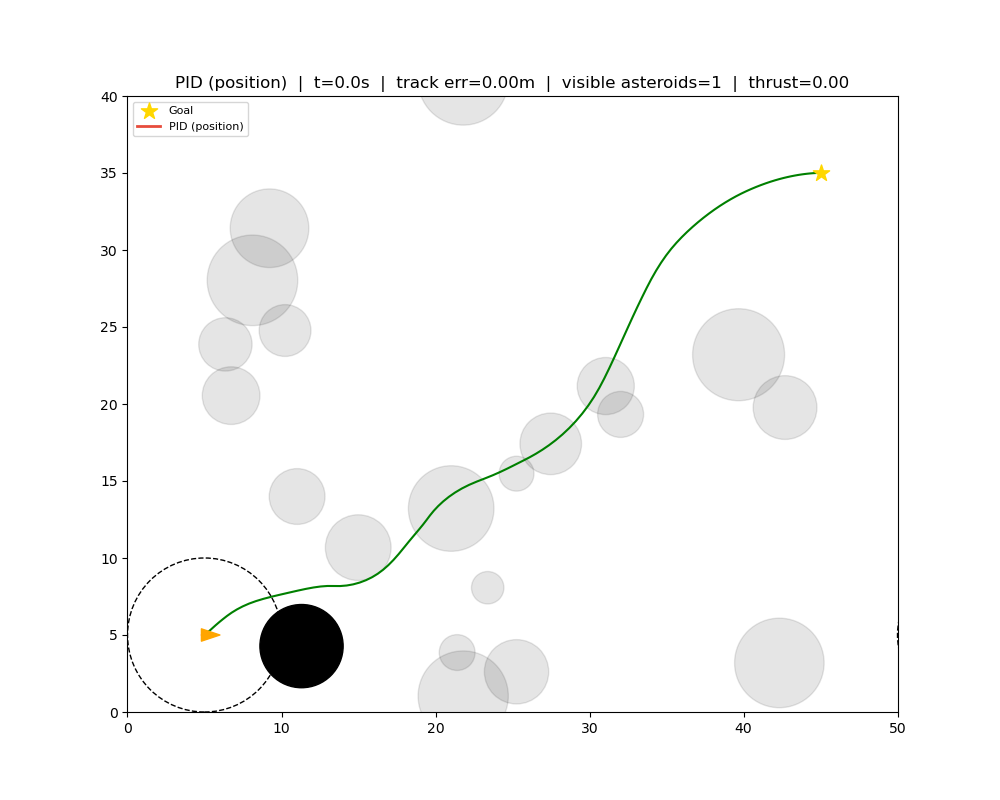

In [ ]:
# Setup the figure once
_first = list(results.keys())[0]
fig_anim, ax_anim = env.plot(
    state   = start_state,
    plan    = xs_nom,
    history = results[_first]['history'][:1],
)
ax_anim.scatter(*goal_position, s=150, marker='*', color='gold', zorder=25, label='Goal')
# Actual path line — updated each frame
_path_line, = ax_anim.plot([], [], lw=2, zorder=20, color=COLORS[_first], label=_first)
ax_anim.legend(loc='upper left', fontsize=8)

@interact(
    controller=Dropdown(
        options=list(results.keys()),
        value=_first,
        description='Controller',
        style={'description_width': 'initial'},
    ),
    k=IntSlider(min=0, max=T, step=1, value=0, description='Step k'),
)
def animate_navigation(controller=_first, k=0):
    res      = results[controller]
    history  = res['history']       # (T+1, 5)
    controls = res['controls']      # (T,   2)

    thrust = float(np.abs(controls[min(k, T-1), 1])) / A_LIMIT

    # Update environment plot: spacecraft pose, sensing circle, asteroid positions
    env.at_time(k * dt).plot(
        state         = history[k],
        plan          = xs_nom,           # green nominal ahead
        history       = history[:k+1],    # blue trail
        scaled_thrust = thrust,
        sensor        = LIMITED_SENSING,  # show sensing circle
        ax            = ax_anim,
    )

    # Overlay actual path in controller colour
    _path_line.set_data(history[:k+1, 0], history[:k+1, 1])
    _path_line.set_color(COLORS[controller])
    _path_line.set_label(controller)

    # Status
    track_err = float(np.linalg.norm(history[k, :2] - xs_nom[k, :2]))
    visible   = res['sensed_asteroids'][min(k, T-1)]
    #status    = '✓ goal' if res['success'] else ('✗ collision' if res['collision'] else '...')

    ax_anim.set_title(
        f"{controller}  |  t={k*dt:.1f}s  |  "
        f"track err={track_err:.2f}m  |  "
        f"visible asteroids={visible}  |  "
        f"thrust={controls[min(k,T-1),1]:.2f}"
    )
    ax_anim.legend(loc='upper left', fontsize=8)
    fig_anim.canvas.draw_idle()

In [ ]:
print(f"Goal position: {goal_position}")
print(f"Goal threshold: 2.0m\n")
for name, res in results.items():
    final_pos  = res['history'][-1, :2]
    dist_final = np.linalg.norm(final_pos - goal_position)
    min_dist   = np.min(np.linalg.norm(res['history'][:, :2] - goal_position, axis=1))
    print(f"{name:<22} | final_pos=({final_pos[0]:.1f},{final_pos[1]:.1f})"
          f" | dist_at_end={dist_final:.2f}m"
          f" | closest_ever={min_dist:.2f}m"
          f" | collision={res['collision']}"
          f" | success={res['success']}"
          f" | traversal_time={res['traversal_time']}")

Goal position: [45. 35.]
Goal threshold: 2.0m

PID (position)         | final_pos=(53.9,37.5) | dist_at_end=9.21m | closest_ever=4.82m | collision=True | success=False | traversal_time=125
PID (full-state)       | final_pos=(43.9,38.4) | dist_at_end=3.53m | closest_ever=3.53m | collision=True | success=False | traversal_time=125
State Feedback         | final_pos=(45.0,35.0) | dist_at_end=0.01m | closest_ever=0.01m | collision=True | success=False | traversal_time=111
Inf-Horizon LQR        | final_pos=(72.2,50.6) | dist_at_end=31.35m | closest_ever=3.99m | collision=True | success=False | traversal_time=125


---
## 6. Tracking Error & Control Effort over Time

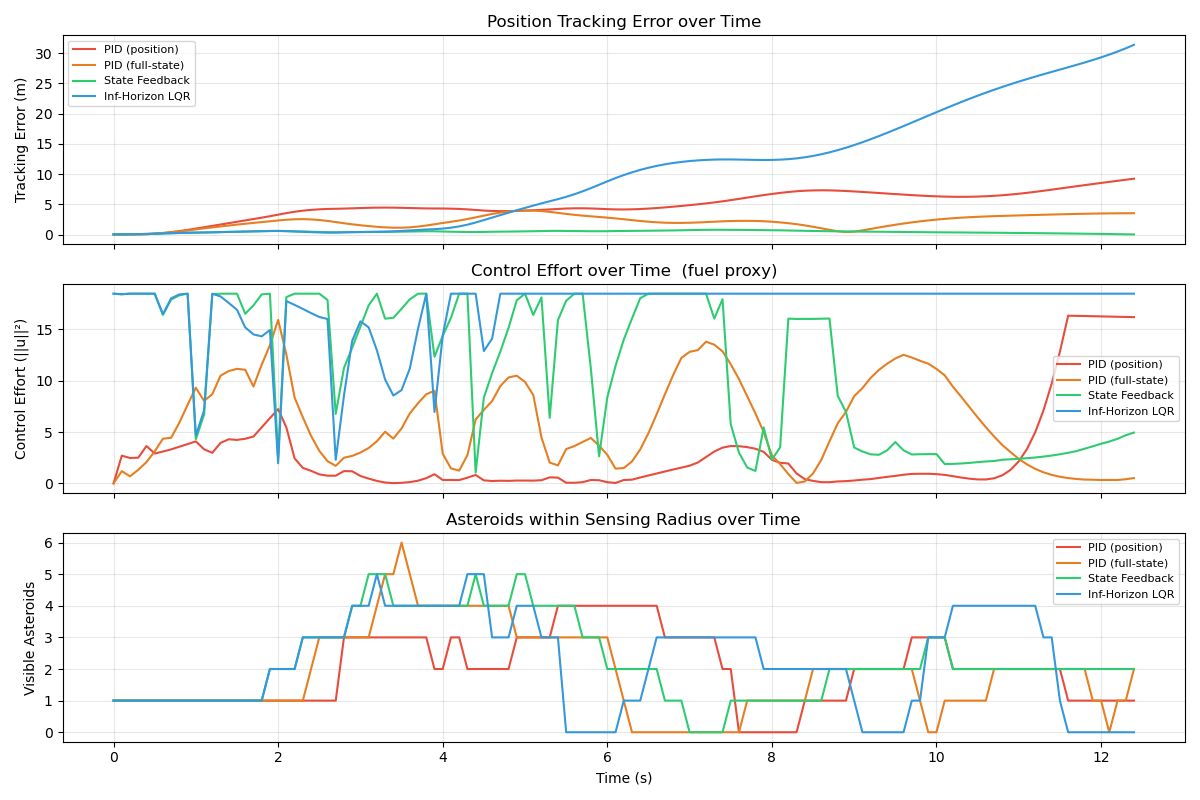

In [ ]:
steps = np.arange(T) * dt
fig_ts, (ax_track, ax_effort, ax_sens) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for name, res in results.items():
    ax_track.plot(steps, res['tracking_errors'],
                  color=COLORS[name], label=name, lw=1.5)
    ax_effort.plot(steps, res['control_efforts'],
                   color=COLORS[name], label=name, lw=1.5)
    ax_sens.plot(steps, res['sensed_asteroids'],
                 color=COLORS[name], label=name, lw=1.5)

ax_track.set_ylabel('Tracking Error (m)')
ax_track.set_title('Position Tracking Error over Time')
ax_track.legend(fontsize=8); ax_track.grid(alpha=0.3)

ax_effort.set_ylabel('Control Effort (||u||²)')
ax_effort.set_title('Control Effort over Time  (fuel proxy)')
ax_effort.legend(fontsize=8); ax_effort.grid(alpha=0.3)

ax_sens.set_ylabel('Visible Asteroids')
ax_sens.set_xlabel('Time (s)')
ax_sens.set_title('Asteroids within Sensing Radius over Time')
ax_sens.legend(fontsize=8); ax_sens.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Metrics Comparison
20-trial benchmark across random asteroid configurations.

In [ ]:
from utils.metrics import evaluate_controller

NUM_TRIALS = 20
benchmark_results = {}

for name, ctrl in controllers.items():
    print(f'\nEvaluating: {name}')
    if hasattr(ctrl, 'prepare'):
        ctrl.prepare(xs_nom, us_nom)
    metrics = evaluate_controller(
        ctrl, dynamics, xs_nom, us_nom,
        start_state, goal_position,
        T, dt,
        num_asteroids = NUM_ASTEROIDS,
        num_trials    = NUM_TRIALS,
        density_label = name,
        verbose       = True,
    )
    benchmark_results[name] = metrics

print('\nDone.')


Evaluating: PID (position)
  [PID (position)] Trial 01/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=0%
  [PID (position)] Trial 02/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=0%
  [PID (position)] Trial 03/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=7%
  [PID (position)] Trial 04/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=12%
  [PID (position)] Trial 05/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=53%
  [PID (position)] Trial 06/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=46%
  [PID (position)] Trial 07/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=23%
  [PID (position)] Trial 08/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=44%
  [PID (position)] Trial 09/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=18%
  [PID (position)] Trial 10/20  ✗ collision  | fuel= 349.64  track=4.88m  time=125  progress=1%
  [PID

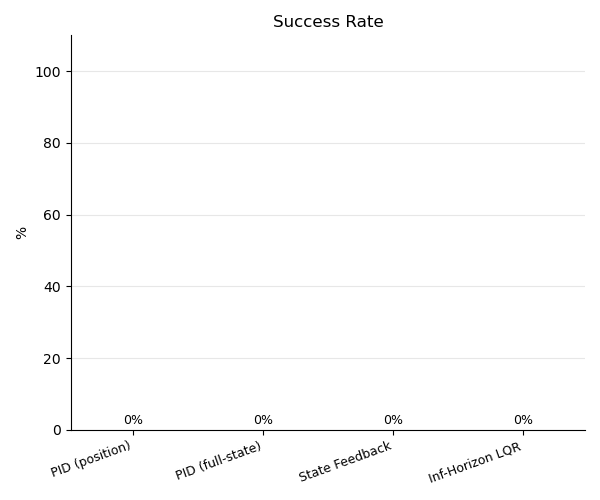

Saved → outputs/metric_success_rate.png


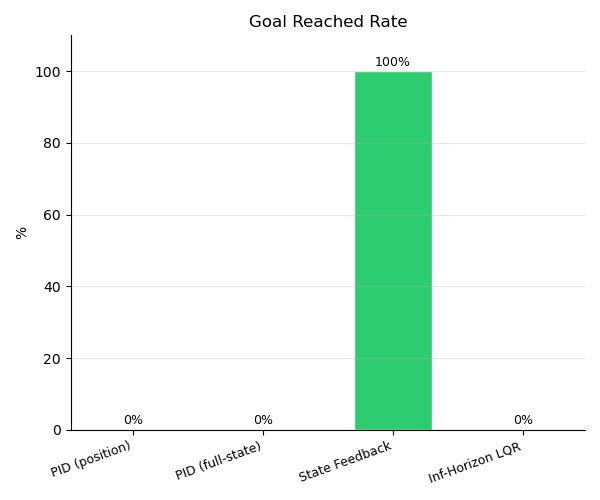

Saved → outputs/metric_goal_reached.png


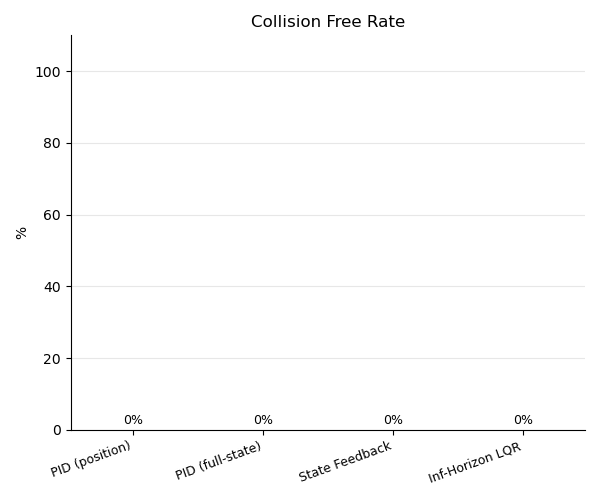

Saved → outputs/metric_collision_free.png


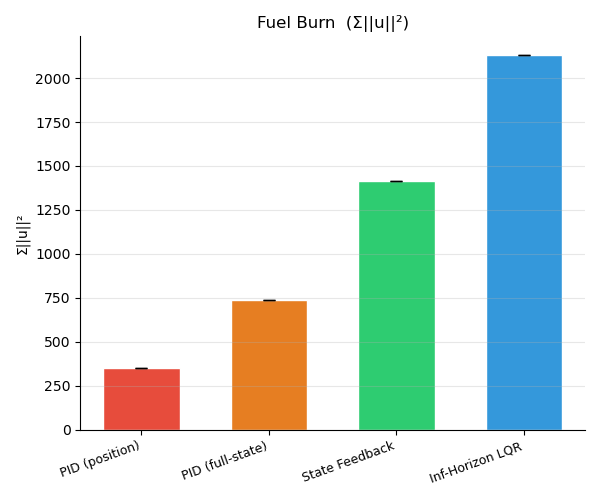

Saved → outputs/metric_fuel_burn.png


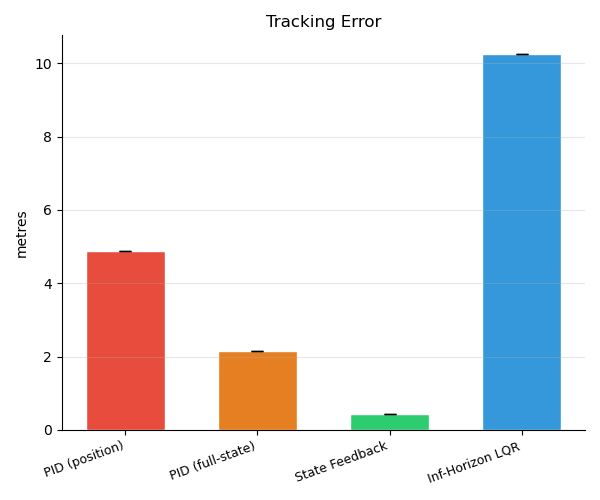

Saved → outputs/metric_tracking_error.png


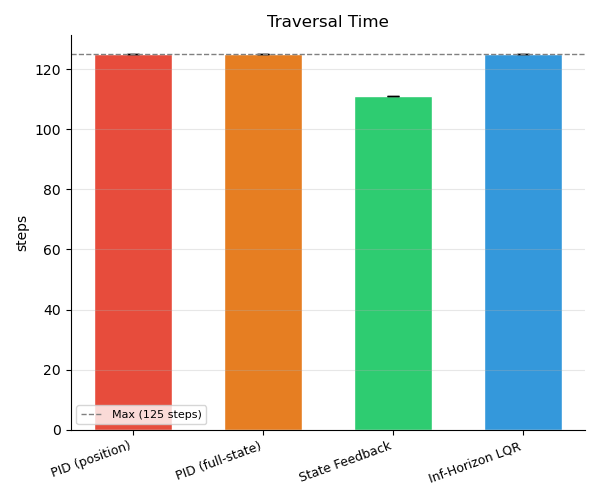

Saved → outputs/metric_traversal_time.png


In [ ]:
names  = list(benchmark_results.keys())
colors = [COLORS[n] for n in names]
x      = np.arange(len(names))
w      = 0.6

def save_bar(values, errors, title, filename, ylabel='', ylim=None,
             hline=None, hline_label=None, show_pct=False):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar(x, values, yerr=errors, color=colors, width=w,
           edgecolor='white', capsize=4 if errors else 0)
    if show_pct:
        for i, v in enumerate(values):
            ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=9)
    if hline is not None:
        ax.axhline(hline, color='gray', linestyle='--', lw=1, label=hline_label)
        ax.legend(fontsize=8)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'../outputs/{filename}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → outputs/{filename}')

# Success Rate
save_bar(
    values    = [benchmark_results[n]['success_rate'] * 100 for n in names],
    errors    = None,
    title     = 'Success Rate',
    filename  = 'metric_success_rate.png',
    ylabel    = '%',
    ylim      = (0, 110),
    show_pct  = True,
)

# Goal Reached Rate
save_bar(
    values    = [benchmark_results[n]['goal_reached_rate'] * 100 for n in names],
    errors    = None,
    title     = 'Goal Reached Rate',
    filename  = 'metric_goal_reached.png',
    ylabel    = '%',
    ylim      = (0, 110),
    show_pct  = True,
)

# Collision Free Rate
save_bar(
    values    = [benchmark_results[n]['collision_free_rate'] * 100 for n in names],
    errors    = None,
    title     = 'Collision Free Rate',
    filename  = 'metric_collision_free.png',
    ylabel    = '%',
    ylim      = (0, 110),
    show_pct  = True,
)

# Fuel Burn
save_bar(
    values    = [benchmark_results[n]['fuel_burn_mean'] for n in names],
    errors    = [benchmark_results[n]['fuel_burn_std']  for n in names],
    title     = 'Fuel Burn  (Σ||u||²)',
    filename  = 'metric_fuel_burn.png',
    ylabel    = 'Σ||u||²',
)

# Tracking Error
save_bar(
    values    = [benchmark_results[n]['tracking_error_mean'] for n in names],
    errors    = [benchmark_results[n]['tracking_error_std']  for n in names],
    title     = 'Tracking Error',
    filename  = 'metric_tracking_error.png',
    ylabel    = 'metres',
)

# Traversal Time
save_bar(
    values      = [benchmark_results[n]['traversal_time_mean'] for n in names],
    errors      = [benchmark_results[n]['traversal_time_std']  for n in names],
    title       = 'Traversal Time',
    filename    = 'metric_traversal_time.png',
    ylabel      = 'steps',
    hline       = T,
    hline_label = f'Max ({T} steps)',
)

In [ ]:
# ── Summary table
print(f'\n{"Controller":<22} {"Success":>8} {"Fuel Burn":>14} {"Track Err":>14} {"Time":>10} {"Progress":>10}')
print('-' * 85)
for name in names:
    m = benchmark_results[name]
    print(
        f'{name:<22} '
        f'{m["success_rate"]*100:>7.0f}%  '
        f'{m["fuel_burn_mean"]:>7.2f}±{m["fuel_burn_std"]:.2f}  '
        f'{m["tracking_error_mean"]:>7.2f}±{m["tracking_error_std"]:.2f}  '
        f'{m["traversal_time_mean"]:>7.1f}±{m["traversal_time_std"]:.1f}  '
        f'{m["progress_mean"]:>6.1f}±{m["progress_std"]:.1f}%'
    )


Controller              Success      Fuel Burn      Track Err       Time   Progress
-------------------------------------------------------------------------------------
PID (position)               0%   349.64±0.00     4.88±0.00    125.0±0.0     0.1±0.1%
PID (full-state)             0%   739.56±0.00     2.15±0.00    125.0±0.0     0.1±0.1%
State Feedback               0%  1412.72±0.00     0.44±0.00    111.0±0.0     3.5±3.5%
Inf-Horizon LQR              0%  2130.51±0.00    10.25±0.00    125.0±0.0    49.9±49.9%
